In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  


c:\Users\mstaw\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#load Dataset
df = pd.read_csv(r"C:\Users\mstaw\Desktop\e commerce analysis\data.csv", encoding="latin1")
#Quick check if Data loaded correctly

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
# Data Cleanup
df['InvoiceDate'] = pd.to_datetime(df.InvoiceDate)
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


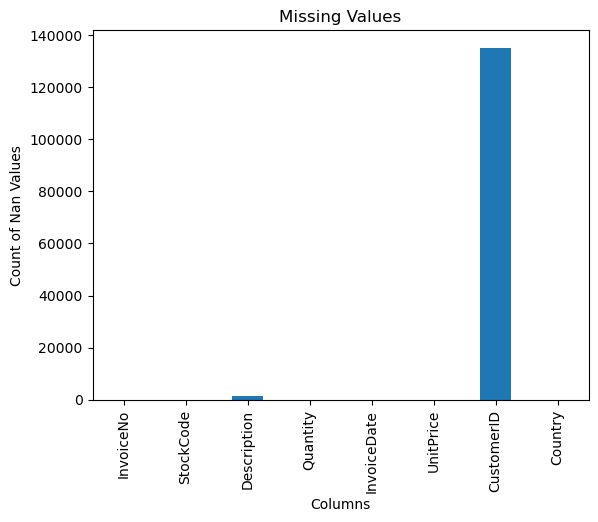

In [4]:
df_na = df.isna().sum()
df_na.plot(kind='bar')
plt.title('Missing Values')
plt.xlabel('Columns')
plt.ylabel('Count of Nan Values')
plt.show()


In [5]:
#Checking for Nan values
pd.isna(df)
#Dropping rows with Nan values
df.dropna(inplace=True)
df.isna().sum()


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [6]:
#How many orders were cancelled?
negativ_qt_loc = df.loc[df['Quantity'] < 0,['Quantity']]
print(f'{len(negativ_qt_loc)} orders were cancelled')

8905 orders were cancelled


In [7]:
# Creating new column
def ifcanceled(number):
    if number < 0:
        return 'Canceled'
    else:
        return 'Endorsed'
        
df['StatusofOrder'] = df.Quantity.apply(ifcanceled)
df.StatusofOrder.value_counts()

StatusofOrder
Endorsed    397924
Canceled      8905
Name: count, dtype: int64

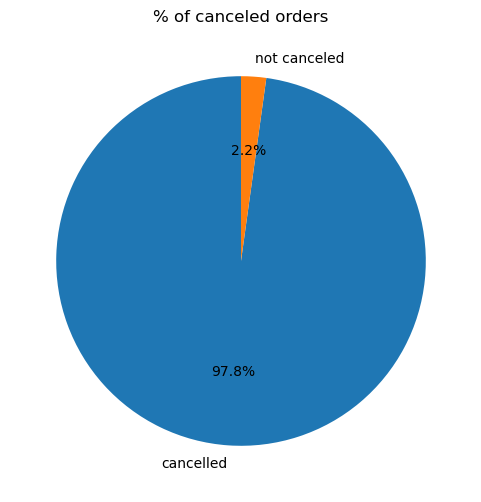

In [8]:
#plotting the results
status_counted = df.StatusofOrder.value_counts()
plt.figure(figsize=(6,6))
plt.pie(status_counted,labels=['cancelled','not canceled'],startangle=90,autopct='%1.1f%%')
plt.title('% of canceled orders')
plt.show()

In [9]:
#Which country got the most orders 
top_10 = df.Country.value_counts().head(10)
top_10_list = [(f'{country}:{number}')  for (country,number) in top_10.items()]
top_10_list


['United Kingdom:361878',
 'Germany:9495',
 'France:8491',
 'EIRE:7485',
 'Spain:2533',
 'Netherlands:2371',
 'Belgium:2069',
 'Switzerland:1877',
 'Portugal:1480',
 'Australia:1259']

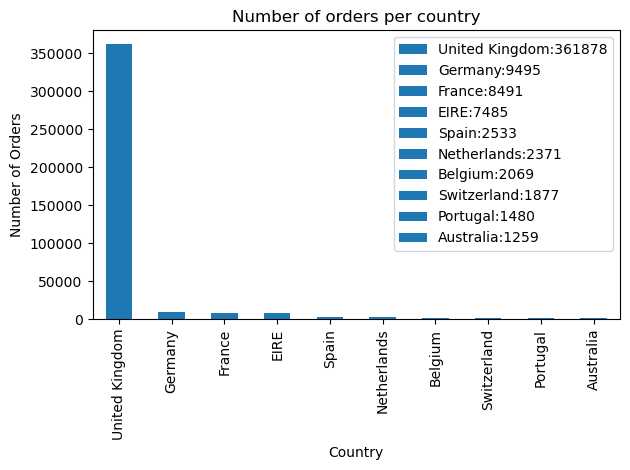

In [10]:
#Plotting the results
ax = top_10.plot(kind='bar')
plt.ylabel('Number of Orders')
plt.title('Number of orders per country')
plt.legend(top_10_list,ncol=1)
plt.legend(
    ax.patches,            
    top_10_list,           
    ncol=1,                
    loc='upper right'
)
plt.tight_layout()
plt.savefig('order_number_per_country.png', dpi=300, bbox_inches='tight')

plt.show()




In [11]:
#Creating a new column: Revenue(only counted if the order wasn't cancelled)
df['Revenue'] = df.Quantity * df.UnitPrice
df['Revenue'] = df.Revenue.apply(lambda x: x if x > 0 else 0)
df.loc[df['Revenue'] <0, ['Revenue']].count()


Revenue    0
dtype: int64

In [12]:
#saving edited df
df.to_pickle('data_frame.pkl')